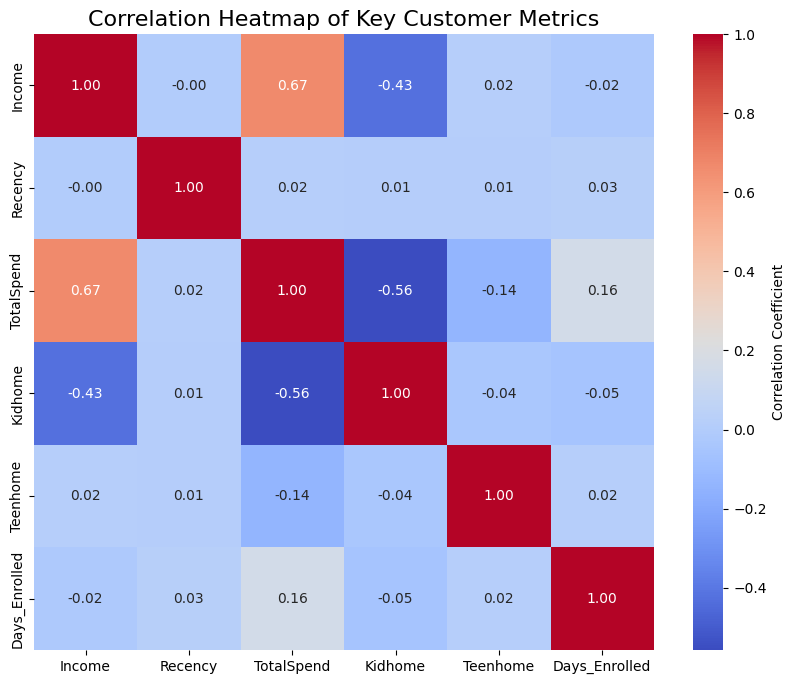

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.columns = df.columns.str.strip().str.replace(' ', '_')

df_clean = df.dropna(subset=['Income']).copy()
df_clean['Income'] = pd.to_numeric(df_clean['Income'], errors='coerce')

spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['TotalSpend'] = df_clean[spending_cols].sum(axis=1)

df_corr = df_clean[['Income', 'Recency', 'TotalSpend', 'Kidhome', 'Teenhome', 'Dt_Customer']].copy()

df_corr['Dt_Customer'] = pd.to_datetime(df_corr['Dt_Customer'], format='%d-%m-%Y', errors='coerce')

reference_date = pd.to_datetime('2014-06-30')
df_corr['Days_Enrolled'] = (reference_date - df_corr['Dt_Customer']).dt.days

numerical_cols = ['Income', 'Recency', 'TotalSpend', 'Kidhome', 'Teenhome', 'Days_Enrolled']
correlation_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Key Customer Metrics', fontsize=16)
plt.show()